<img src="../img/GTK_Logo_Social Icon.jpg" width=175 align="right" />

# Worksheet 9.3: PyTorch in 20 Minutes

*Module 9 — Build Your Own LLM.* Cells marked **TODO** are yours to fill in; everything else is ready to run.

Before we build a language model, we need just enough **PyTorch** to read and tweak the code in the labs that follow. PyTorch is the library most real LLMs are built with. You can think of it as three things bolted together:

1. **Tensors** — multi-dimensional arrays (like NumPy) that can live on a GPU.
2. **Autograd** — it automatically computes the calculus (gradients) needed to learn.
3. **A training loop** — predict → measure error → nudge the numbers → repeat.

That's the whole game. By the end of this short lab you'll have trained a model — a very simple one (a straight line), but trained the exact same way GPT is.


## 1. Setup and picking a device

PyTorch can run on a regular **CPU** or, if you have one, a **GPU** (much faster for big models). The cell below picks the best device available automatically — you don't have to change anything whether you're on a laptop or a GPU machine.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Pick the best available device: NVIDIA GPU (cuda), Apple Silicon (mps), or CPU.
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", device)
print("PyTorch version:", torch.__version__)

Using device: mps
PyTorch version: 2.13.0


## 2. Tensors

A **tensor** is just an array of numbers. Math on tensors happens element-by-element, and every operation can run on a GPU. If you've used NumPy, this will feel familiar.

In [2]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print("a        =", a)
print("a + b    =", a + b)
print("a * b    =", a * b)      # element-wise multiply
print("a.shape  =", a.shape)
print("a.mean() =", a.mean())

a        = tensor([1., 2., 3.])
a + b    = tensor([11., 22., 33.])
a * b    = tensor([10., 40., 90.])
a.shape  = torch.Size([3])
a.mean() = tensor(2.)


Tensors can have more than one dimension. The single most important operation in a neural network is **matrix multiplication** (`@`). Watch the shapes: a `(2,3)` times a `(3,4)` gives a `(2,4)`.

In [3]:
M = torch.randn(2, 3)   # 2x3 matrix of random numbers
N = torch.randn(3, 4)   # 3x4 matrix
P = M @ N               # matrix multiply -> 2x4
print("M shape:", M.shape, "| N shape:", N.shape, "| (M @ N) shape:", P.shape)

M shape: torch.Size([2, 3]) | N shape: torch.Size([3, 4]) | (M @ N) shape: torch.Size([2, 4])


## 3. Autograd: PyTorch does the calculus for you

To *learn*, a model needs to know which direction to nudge each number to reduce its error. That direction is the **gradient** (a derivative). You never compute these by hand — PyTorch tracks your operations and works them out when you call `.backward()`.

Below: for `y = x² + 2x + 1`, calculus says `dy/dx = 2x + 2`. At `x = 3` that's `8`. Let's check PyTorch agrees.

In [4]:
# requires_grad=True tells PyTorch to track operations on x so it can differentiate.
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1
y.backward()               # compute dy/dx
print("y       =", y.item())
print("dy/dx   =", x.grad.item(), " (calculus says 2x+2 = 8)")

y       = 16.0
dy/dx   = 8.0  (calculus says 2x+2 = 8)


## 4. The training loop (the heart of all deep learning)

Every model — including GPT — learns with the same four-step loop:

1. **Predict** with the current numbers (the *forward pass*).
2. **Measure** how wrong the prediction is (the *loss*).
3. **Backward**: ask autograd for the gradients.
4. **Update**: nudge each number a small step *downhill* (lower loss).

We'll use it to fit a straight line `y = w·x + b` to noisy data. The true line is `y = 2x + 1`; the model starts from random `w` and `b` and should discover those values.

**TODO:** fill in the loss (step 2) and the parameter update (step 4).

In [ ]:
# Make noisy data that roughly follows y = 2x + 1
torch.manual_seed(42)
X = torch.linspace(-3, 3, 100).unsqueeze(1)     # 100 points, shape (100, 1)
Y = 2 * X + 1 + torch.randn_like(X)             # true line + noise

# Parameters we want to LEARN (start random)
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
learning_rate = 0.05

for step in range(200):
    pred = w * X + b                            # 1. forward pass

    # 2. Measure how wrong we are: the MEAN SQUARED ERROR between pred and Y.
    #    Assign it to `loss`.
    # Your code here...
    raise NotImplementedError("TODO: compute the mean squared error into `loss`")

    loss.backward()                             # 3. gradients

    with torch.no_grad():                       # 4. update (don't track this)
        # Nudge w and b a `learning_rate`-sized step DOWNHILL, i.e. subtract
        # learning_rate * <the parameter's .grad>. Then zero both .grad values
        # with .grad.zero_() so they don't accumulate into the next step.
        # Your code here...
        raise NotImplementedError("TODO: update w and b, then zero their .grad")

    if step % 40 == 0:
        print(f"step {step:3d} | loss {loss.item():6.3f} | w {w.item():.3f} | b {b.item():.3f}")

print(f"\nLearned: y = {w.item():.2f} x + {b.item():.2f}   (target was y = 2x + 1)")

Let's plot it. The red line is what the model learned just by following gradients downhill.

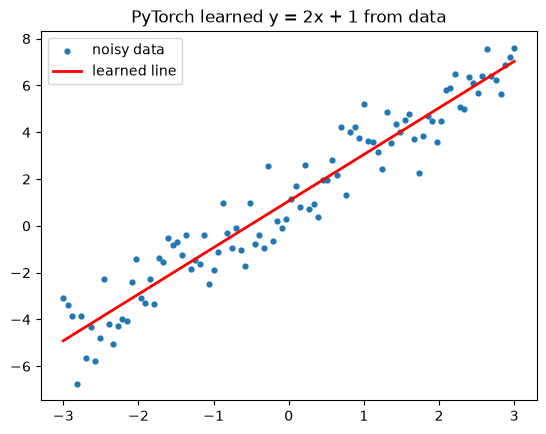

In [6]:
with torch.no_grad():
    plt.scatter(X.numpy(), Y.numpy(), s=12, label="noisy data")
    plt.plot(X.numpy(), (w * X + b).numpy(), color="red", linewidth=2, label="learned line")
    plt.legend(); plt.title("PyTorch learned y = 2x + 1 from data"); plt.show()

## Recap

You just used everything an LLM uses to learn:

- **Tensors** hold the numbers.
- **Autograd** (`.backward()`) computes the gradients.
- **The loop** predict → loss → backward → update is *exactly* how GPT trains. The only difference is scale: instead of 2 numbers (`w`, `b`), GPT adjusts billions, and instead of fitting a line it predicts the next token.

Next: **Worksheet 9.4 — Tokenizers & Embeddings**, where we turn text into numbers a model can read.